# Laser Off Code

In [ ]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

# Set Laser and Powermeters Code

In [ ]:
params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)

# Import

In [52]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
initialise_or_create_database_at("./2026-05-11_SNSPD11.db")
from functions import osc_set_standard, osc_check_standard, capture_trace, capture_trace_simple
from functions import snspd_dark_counts
from functions import snspd_counts_vs_wavelength
from functions import laser_set_standard, laser_get_standard
from functions import snspd_counts_vs_current
import snspd
params = snspd.snspd('snspd11.yaml')

# Set up experiment
exp_name = 'SNSPD11_11_05_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Experiment loaded. Last ID no: 67


In [11]:
import importlib
importlib.reload(snspd)
params = snspd.snspd('snspd11.yaml')

# Instruments

In [3]:
station = Station(config_file="friesland.yaml")
dmm = station.load_instrument("dmm", revive_instance=True)
yoko = station.load_instrument("yoko", revive_instance=True)
# laser = station.load_instrument("laser", revive_instance=True)
# MS = station.load_instrument("mso5", revive_instance=True)
# pm100usb = station.load_instrument("pm100usb", revive_instance=True)
# pm100d = station.load_instrument("pm100d", revive_instance=True) 
# pms120 = station.load_instrument("pms120", revive_instance=True)
tc = station.load_instrument("fridge", revive_instance=True)
# p_att = station.load_instrument("dmm_keithley", revive_instance=True) # excluding from snapshot because none of the parameters work anyway

In [8]:
params.device_line_1_name

'R9C9'

Negative voltages for this device due to polarity of four wire connection

In [13]:
params.critical_current(dmm=dmm, yoko=yoko, tc=tc, currents=np.arange(0,-15.25e-6, -0.25e-6), device_name=params.device_line_1_name, station=station)

update station
Starting experimental run with id: 41. 
41
Starting current 0.0
Starting current -2.5e-07
Starting current -5e-07
Starting current -7.5e-07
Starting current -1e-06
Starting current -1.25e-06
Starting current -1.5e-06
Starting current -1.75e-06
Starting current -2e-06
Starting current -2.25e-06
Starting current -2.5e-06
Starting current -2.75e-06
Starting current -3e-06
Starting current -3.25e-06
Starting current -3.5e-06
Starting current -3.75e-06
Starting current -4e-06
Starting current -4.25e-06
Starting current -4.5e-06
Starting current -4.75e-06
Starting current -5e-06
Starting current -5.25e-06
Starting current -5.5e-06
Starting current -5.75e-06
Starting current -6e-06
Starting current -6.25e-06
Starting current -6.5e-06
Starting current -6.75e-06
Starting current -7e-06
Starting current -7.25e-06
Starting current -7.5e-06
Starting current -7.75e-06
Starting current -8e-06
Starting current -8.25e-06
Starting current -8.5e-06
Starting current -8.75e-06
Starting curr

In [ ]:
params.critical_current(dmm=dmm, yoko=yoko, tc=tc, currents=np.arange(0,-15.25e-6, -0.25e-6), device_name=params.device_line_1_name, station=station)

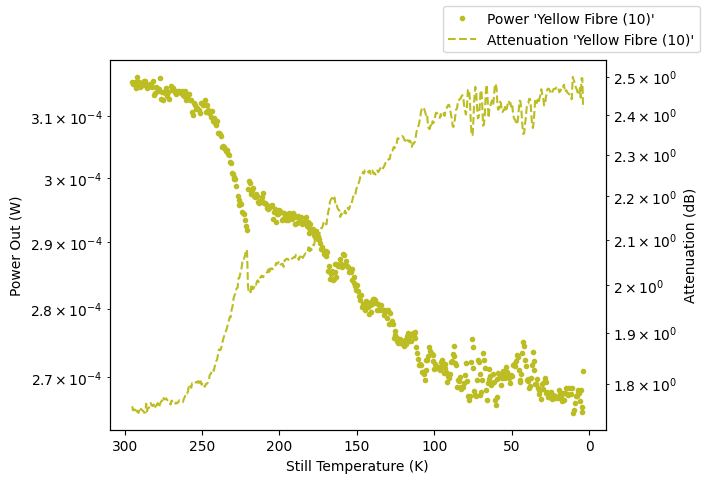

In [26]:
db10 = "./2026-04-17_SNSPD10.db"
exname10 = 'SNSPD10'
sampname10 = '00'
ID = 7
data_10 = params.load_id_from_database(db10, exname10, sampname10, ID).get_parameter_data()
power10_10 = data_10['power10']['power10']
power90_10 = data_10['power90']['power90']
attenuation_10 = data_10['attenuation']['attenuation']
still_temp_10 = data_10['still_temp']['still_temp']

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

ax1.semilogy(still_temp_10, power10_10, '.', color = 'tab:olive', label='Power \'Yellow Fibre (10)\'')
ax1.set_xlabel('Still Temperature (K)')
ax1.set_ylabel('Power Out (W)')
ax1.invert_xaxis()

ax2.semilogy(still_temp_10, attenuation_10, '--', color='tab:olive', label='Attenuation \'Yellow Fibre (10)\'') 
ax2.set_xlabel('Still Temperature (K)')
ax2.set_ylabel('Attenuation (dB)')

fig.legend()


In [39]:
def avg_from_calibration(ID, key):
    return np.average(load_by_id(params.att_screw_calibration_id).get_parameter_data()[key][key])

att_screw = avg_from_calibration(params.att_screw_calibration_id, 'attenuation')


In [47]:
def avg_from_calibration(ID, key):
    return np.average(load_by_id(ID).get_parameter_data()[key][key])
                      
att_blue = [avg_from_calibration(ID, 'attenuation') for ID in ID_blue_calibration]

In [49]:
def avg_from_calibration(ID, key):
    return np.average(load_by_id(ID).get_parameter_data()[key][key])

att_screw = avg_from_calibration(params.att_screw_calibration_id, 'attenuation')

ID_blue_calibration = list(np.arange(22, 39)) + [40] + list(np.arange(42, 49)) 
att_blue = [avg_from_calibration(ID, 'attenuation') for ID in ID_blue_calibration]
power_90_avg = np.average([avg_from_calibration(ID, 'power90') for ID in ID_blue_calibration])
v_attenuator_range = [load_by_id(ID).get_parameter_data()['v_attenuator']['v_attenuator'][0] for ID in ID_blue_calibration]


db10 = "./2026-04-17_SNSPD10.db"
exname10 = 'SNSPD10'
sampname10 = '00'
ID = 7
attenuation_10 = params.load_id_from_database(db10, exname10, sampname10, ID).get_parameter_data()['attenuation']['attenuation']
still_temp_10 = params.load_id_from_database(db10, exname10, sampname10, ID).get_parameter_data()['still_temp']['still_temp']

fibre_attenuation = attenuation_10[-1]/2 # data taken cooling, last data point (coldest)
print(still_temp_10[-1])


3.894396


In [51]:
np.average([avg_from_calibration(ID, 'power90') for ID in ID_blue_calibration])

ValueError: Run with run_id 22 does not exist in the database: D:\SNSPD\SNSPD2\2026-04-17_SNSPD10.db

In [31]:
total_attenuation = att_screw + ID_blue_calibration + fibre_attenuation

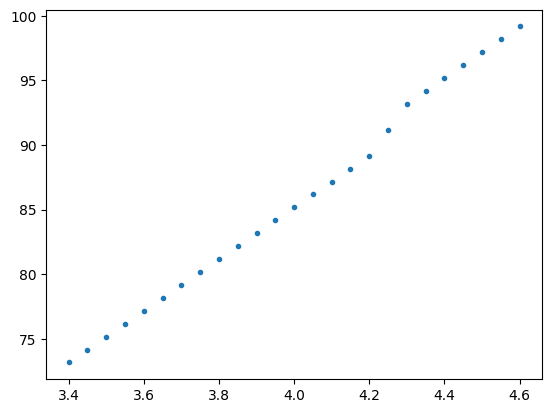

In [37]:
plt.plot(v_attenuator, total_attenuation, '.') 

In [36]:
v_attenuator = [load_by_id(ID).get_parameter_data()['v_attenuator']['v_attenuator'][0] for ID in ID_blue_calibration]
